In [1]:
import plotly.express as px
from sklearn.decomposition import PCA
import scipy.io as sio
import pandas as pd
import numpy as np

In [2]:
phase2_data = sio.loadmat('../data/phase2_data_20220215.mat')
print(phase2_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'mine', 'note', 'wavdir', 'x', 'y', 'SNR'])


In [3]:

df_x  = pd.DataFrame(phase2_data["x"].T)
df_y  = pd.DataFrame(phase2_data["y"].T, columns=["y"])
# df_mine = pd.DataFrame(phase2_data["mine"].T, columns=["mine"])

df = pd.concat([df_x, df_y], axis=1, join="inner")

df = df.dropna()

display(df)

,0,1,2,3,4,5,6,7,8,9,...,4791,4792,4793,4794,4795,4796,4797,4798,4799,y
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000031,0.000000,0.000031,0.000000,-0.000061,0.000000,0.0
1,-0.000061,-0.000031,-0.000092,-0.000031,-0.000061,-0.000061,-0.000061,-0.000061,-0.000031,-0.000061,...,-0.000031,0.000031,-0.000061,0.000000,0.000031,0.000122,0.000031,0.000092,0.000092,0.0
2,0.000000,-0.000122,0.000000,-0.000061,-0.000031,-0.000031,0.000000,-0.000031,0.000031,-0.000061,...,0.000183,0.000244,0.000031,0.000061,0.000092,0.000000,0.000031,-0.000153,-0.000122,0.0
3,0.000061,-0.000031,0.000000,0.000000,0.000000,0.000000,-0.000031,0.000000,0.000000,-0.000031,...,0.000122,0.000153,0.000153,0.000214,0.000183,0.000244,0.000244,0.000305,0.000275,0.0
4,0.000000,0.000031,-0.000061,0.000061,0.000000,0.000000,0.000031,-0.000031,-0.000031,0.000000,...,0.000244,0.000275,0.000214,0.000366,0.000275,0.000397,0.000244,0.000458,0.000366,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9918,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.036957,0.042694,0.047516,0.050690,0.052979,0.053772,0.053741,0.054047,0.054321,1.0
9919,0.000031,0.000000,-0.000061,-0.000031,-0.000061,0.000092,0.000031,0.000122,0.000153,0.000183,...,-0.015991,-0.017029,-0.017975,-0.018951,-0.020050,-0.020691,-0.021271,-0.021759,-0.021851,1.0
9920,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.025238,-0.031494,-0.038025,-0.046021,-0.053101,-0.060120,-0.068390,-0.076202,-0.082703,1.0
9921,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.022125,-0.022217,-0.022217,-0.022186,-0.021851,-0.021332,-0.020721,-0.019806,-0.018616,1.0


In [4]:
X = df.iloc[:, :-1]

pca = PCA(n_components=2)

components = pca.fit_transform(X)

new_axis = phase2_data["y"].T.copy()
new_axis[new_axis == 0] = -1

df_components = pd.DataFrame(components, columns=["PC1", "PC2"])
df_new_axis = pd.DataFrame( new_axis, columns=["z"])

df_kernel = pd.concat([df_components, df_new_axis], axis=1, join="inner")

one_count = np.sum(df_kernel["z"] == 1)
print("one_count", one_count)
zero_count = np.sum(df_kernel["z"] == -1)
print("zero_count", zero_count)

fig = px.scatter_3d(df_kernel, x="PC1", y="PC2", z="z", color=df['y'])
fig.show()
fig.write_image("../assets/p2_pca_3d.png")

one_count 3124
zero_count 3856


In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

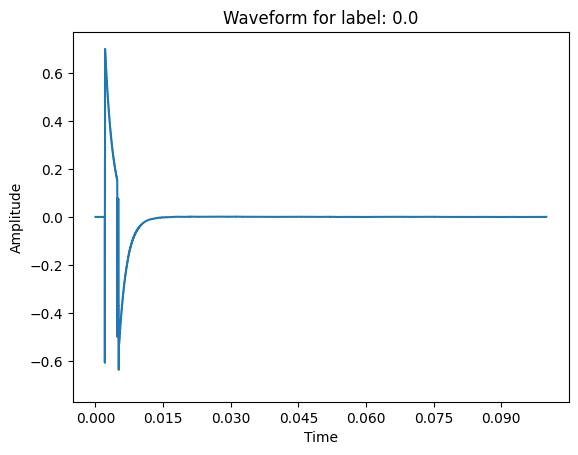

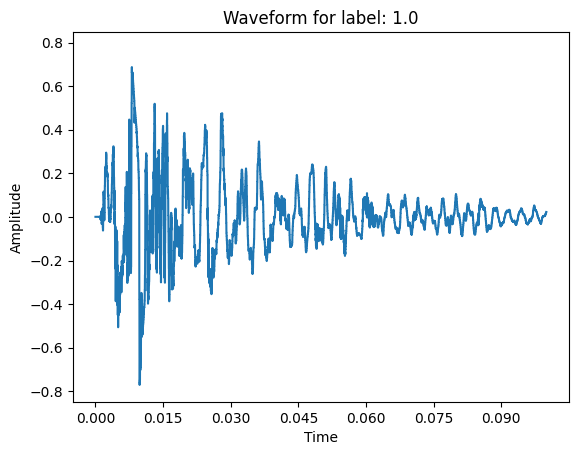

In [17]:
example = df.iloc[800, :-1].values
label = df.iloc[800, -1]
sample_rate_phase1 = 48000

#Displaying 1st Waveform
plt.figure()
librosa.display.waveshow(example, sr=sample_rate_phase1)
plt.title('Waveform for label: {}'.format(label))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

example9922 = df.iloc[8430, :-1].values
label9922 = df.iloc[8430, -1]
#Displaying 2nd Waveform
plt.figure()
librosa.display.waveshow(example9922, sr=sample_rate_phase1)
plt.title('Waveform for label: {}'.format(label9922))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()


cumulative_variance: [0.08978018 0.16540565 0.20764453 ... 1.         1.         1.        ]


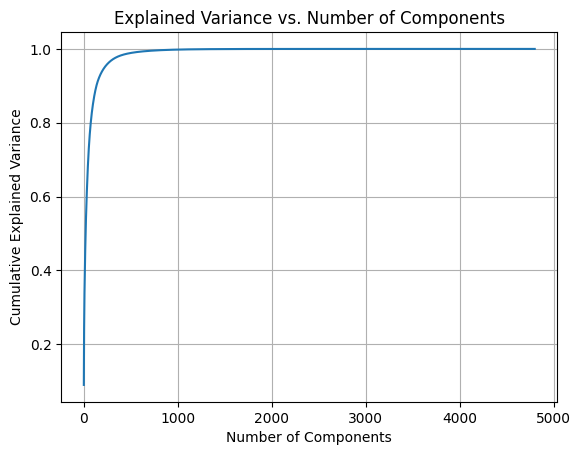

Number of components retaining 95% variance: 222
Number of components retaining 70% variance: 48
Number of components retaining 80% variance: 75


In [18]:
# Assuming X is your data
pca = PCA(n_components=None)
pca.fit(X)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("cumulative_variance:", cumulative_variance)

# Plot cumulative explained variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# Choose n_components based on the plot or a threshold
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Number of components retaining 95% variance: {n_components}')

n_components = np.argmax(cumulative_variance >= 0.70) + 1
print(f'Number of components retaining 70% variance: {n_components}')

n_components = np.argmax(cumulative_variance >= 0.80) + 1
print(f'Number of components retaining 80% variance: {n_components}')

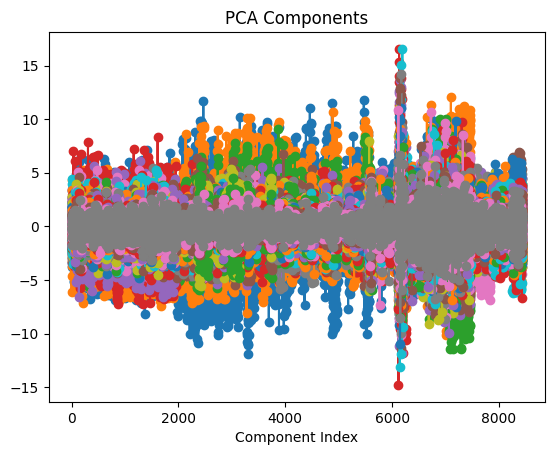

In [20]:
# Apply PCA with the selected number of components
pca_final = PCA(n_components=48)
X_reduced = pca_final.fit_transform(X)

df_pca_plot = pd.DataFrame(X_reduced, columns=[f"PC{i+1}" for i in range(48)])
plt.figure()
plt.plot(df_pca_plot, marker='o', linestyle='-')
plt.title('PCA Components')
plt.xlabel('Component Index')
plt.show()

In [21]:
from IPython.display import Audio

print("label", label)
Audio(example, rate=sample_rate_phase1)


label 0.0
